In [114]:
import numpy as np
import networkx as nx
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [124]:

#continuous dynamics
def continuous_dynamics(t, x_vec, A, B, D):
    #this is just the continuous time SIS networked model dynamics
    dx_dt = -D @ x_vec[:-1] + (np.eye(A.shape[0]) - np.diag(x_vec[:-1])) @ B @ A @ x_vec[:-1]
    #also have a dummy variable forthe cost function, since we are minimizing
    # - sum_{i = 1}^N \integral x_i(t) over the time horizon
    di_dt = np.sum(x_vec[:-1])
    return np.concatenate((dx_dt, [di_dt]))

def simulate_horizon(d_intervals, H, x0_vec, A, B, D, tau_k = 0 ):
    #simulate the dynamics over the time horizon H
    #d_interval is a list of lengths of intervals of a certain guess
    m = len(d_intervals)
    d_final = H - np.sum(d_intervals)
    all_d = np.concatenate((d_intervals, [d_final]))

    #initialize simulation variables
    current_x_vec = x0_vec
    current_B = B
    current_D = D
    current_integral= 0
    current_t = tau_k

    for r, dt in enumerate(all_d):
       dt = max(0.0, dt)
       if dt > 0:
        t_start = current_t
        t_end = current_t + dt
            #simulate the dynamics over the interval [t_start, t_end]
        sol = solve_ivp(continuous_dynamics,
                                [t_start, t_end], 
                                np.concatenate((current_x_vec, [current_integral])), 
                                args=(A, current_B, current_D), 
                                dense_output=False
                                #Im just setting this to false for now since it returns an array hich is easier to handlke
                )
        current_x_vec = sol.y[:-1, -1] #get the last state from this time interval
        current_integral = sol.y[-1, -1] #get the last integral value from this time interval
        current_t = t_end

        if r < m: #if we are not at the last interval, the parameters need to be updated
                #TODO: go back and change these to actually do something interesting
                update_factor = max(0.0, 1.0 - (d_intervals[r] * 0.1))
                    
                current_B = current_B * (1.0 + (d_intervals[r] * 0.1)) 
                current_D = current_D * update_factor
                current_x_vec = current_x_vec * update_factor

    return -1 * current_integral # return the negative of the integral since we are minimizing

def MPC_for_fixed_m(x_vec, A, B, D, H, m):
    #1. have an initial guess for how the intervals should be
    d_guess = np.ones(m) * (H / (m + 1)) #just a uniform guess for now (using m+1 since we dont want an update at the end of the interval horizon)
    # in this case 0.1 min is the delay so we cant update faster than that 
    bounds = [(0.1, H) for _ in range(m)] #bounds for the optimization problem, each interval should be between 0 and H
    #using the above bounds because that is the bounds for each decision variable, which is the lengh of each interval waiting
    def constraint_sum(d_intervals):
        return H - np.sum(d_intervals) #the sum of the intervals should be less than or equal to H
    #make scipy constrint object
    cons = {'type': 'ineq', 'fun': constraint_sum} #the constraint is an inequality, since we want the sum of the intervals to be less than or equal to H
    def objective(d):
        return simulate_horizon(d, H, x_vec, A, B, D) #the objective function is the simulation of the horizon with the given intervals

    #now do the optimization
    result = minimize(
        objective,
        d_guess,
        bounds=bounds,
        constraints=cons,
        method='SLSQP',
        options={'disp': False} #dont need the messages and stuff, letit do its thing
    )
    return result

def get_control_sequence(x_vec, A, B, D, H, m_max):
    #run the MPC for m = 1 to m_max and return the best result
    best_result = None
    best_value = float('inf')
    for m in range(1, m_max + 1):
        result = MPC_for_fixed_m(x_vec, A, B, D, H, m)
        if result.fun < best_value:
            best_value = result.fun
            best_result = result
    return best_result

def simulate_with_control(x_vec, A, B, D, H, m_max, t_total):
    #from the initial condition, get a sequence of control inputs (times to wait)
    #then simulate to the first update time. Apply the first control input/update time
    #then get a new sequence of control inputs from the new state and repeat until the total time is reached
    #Return a list of states at each time step for plotting and analysis
    current_t = 0
    current_x_vec = x_vec
    current_B = B
    current_D = D
    states_over_time = [current_x_vec]
    times_over_time = [current_t]
    while current_t < t_total:
        #get the control sequence for the current state
        result = get_control_sequence(current_x_vec, A, current_B, current_D, H, m_max)
        d_intervals = result.x
        #simulate to the first update time
        dt = d_intervals[0]
        # print("dt: ", dt)
        t_start = current_t
        t_end = current_t + dt
        sol = solve_ivp(continuous_dynamics,
                                [t_start, t_end], 
                                np.concatenate((current_x_vec, [0])), 
                                args=(A, current_B, current_D), 
                                dense_output=False
                )
        this_interval_states = sol.y[:-1, :] #these are all the states over this interval
        this_interval_times = sol.t #these are all the times over this interval
        states_over_time.extend(this_interval_states.T) #add these states to the list of states
        times_over_time.extend(this_interval_times) #add these times to the list of times
        current_x_vec = this_interval_states[:, -1] #get the last state from this interval
        current_t = t_end
        #update the parameters based on the first control input
        #TODO: SHOULD BE THE SAME AS BEFORE< CHANGE THIS TO MAKE SENESE LATER
        update_factor = max(0.0, 1.0 - (dt * 0.1))
        current_B = current_B * (1.0 + (dt * 0.1)) 
        current_D = current_D * update_factor
        current_x_vec = current_x_vec * update_factor
    return np.array(states_over_time), np.array(times_over_time)

        


 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -4.941924213682451
       x: [ 2.169e+00  2.180e+00  2.205e+00]
     nit: 4
     jac: [ 2.639e-04 -3.184e-04 -9.424e-04]
    nfev: 18
    njev: 4


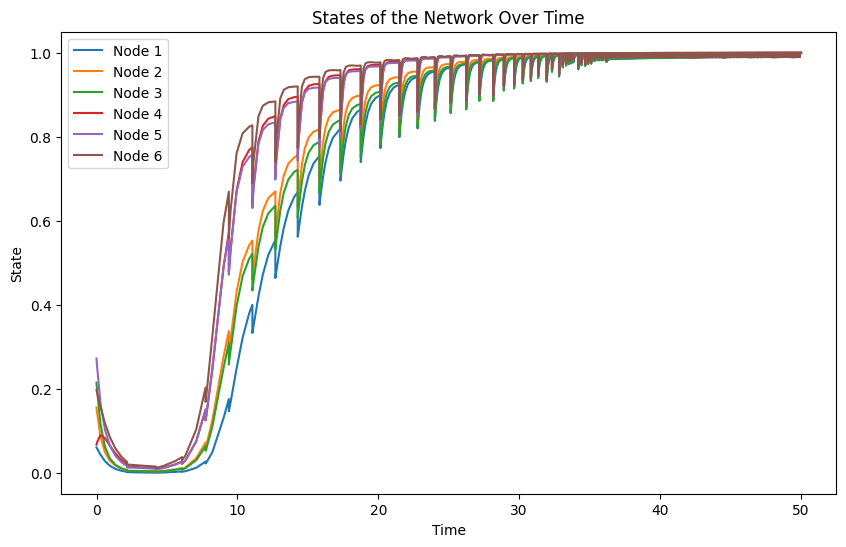

In [127]:
H = 10
m_max = 3 #the max amount of times we can update in a horizon 
n = 6 #number of nodes
p = 0.5 #prob for ER graph 
G = nx.erdos_renyi_graph(n, p)
A = nx.to_numpy_array(G)
#B and D parameters
D = np.diag(np.random.uniform(2, 3, n))
B = np.diag(np.random.uniform(0, 1, n))
#initial condition
x_vec_0 = np.random.uniform(0, .3, n)
#run MPC

optimal_solution = get_control_sequence(x_vec_0, A, B, D, H, m_max)
print(optimal_solution)

#now simulate the system with the control inputs
t_total = 50
states_over_time, times_over_time = simulate_with_control(x_vec_0, A, B, D, H, m_max, t_total)
#plot the states over time
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(times_over_time, states_over_time[:, i], label=f'Node {i+1}')
plt.xlabel('Time')
plt.ylabel('State')
plt.title('States of the Network Over Time')
plt.legend()
plt.show()
